In [1]:
!pip install pennylane scikit-learn pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 111.2 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pennylane as qml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
# Set the base path to the MVTec AD dataset folder on Kaggle
base_path = "/kaggle/input/mvtec-ad"  # update if needed

# Choose one category, e.g., "bottle"
category = "bottle"
train_path = os.path.join(base_path, category, "train/good")

# Get a list of all image file paths (assuming common image extensions)
image_extensions = ["png", "jpg", "jpeg"]
image_files = []
for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(train_path, f"*.{ext}")))
    
print(f"Found {len(image_files)} training images for category '{category}'.")


Found 209 training images for category 'bottle'.


Shape of raw feature vectors: (209, 4096)
Shape after PCA reduction: (209, 2)


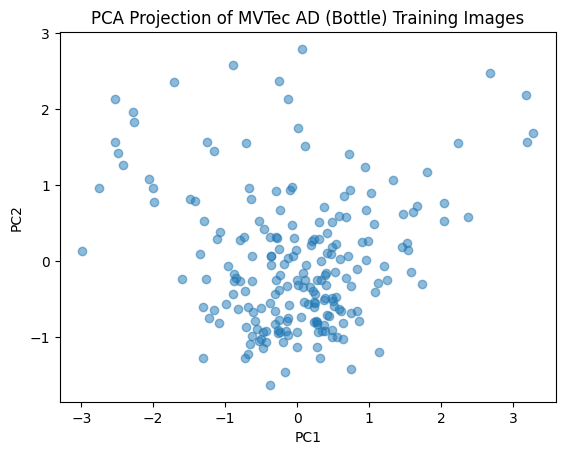

In [5]:
# Define image preprocessing parameters
img_size = (64, 64)  # Resize images to 64x64

def preprocess_image(image_path):
    # Open image, convert to grayscale, and resize
    img = Image.open(image_path).convert("L")  # "L" mode for grayscale
    img = img.resize(img_size)
    # Convert image to numpy array and normalize pixel values to [0, 1]
    img_array = np.array(img, dtype=np.float32) / 255.0
    # Flatten the image into a vector
    return img_array.flatten()

# Process all training images and collect them in a list
all_images = [preprocess_image(fp) for fp in image_files]
all_images = np.array(all_images)  # shape: (num_samples, 64*64)
print("Shape of raw feature vectors:", all_images.shape)

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
features_2d = pca.fit_transform(all_images)
print("Shape after PCA reduction:", features_2d.shape)

# Visualize a scatter of the PCA features (for sanity check)
plt.scatter(features_2d[:, 0], features_2d[:, 1], alpha=0.5)
plt.title("PCA Projection of MVTec AD (Bottle) Training Images")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [6]:
class MVTecDataset(Dataset):
    def __init__(self, features):
        """
        features: numpy array of shape (num_samples, 2)
        """
        self.features = torch.tensor(features, dtype=torch.float32)
    
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, idx):
        return self.features[idx]

# Split data into training and validation sets if desired
train_features, val_features = train_test_split(features_2d, test_size=0.1, random_state=42)
train_dataset = MVTecDataset(train_features)
val_dataset = MVTecDataset(val_features)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")


Training samples: 188, Validation samples: 21


In [10]:
# Set the number of qubits equal to our output dimension (2)
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def generator_circuit(z, weights):
    # Encode latent vector 'z' via RX rotations
    for i in range(n_qubits):
        qml.RX(z[i], wires=i)
    # Apply trainable rotations
    for i in range(n_qubits):
        qml.RY(weights[i, 0], wires=i)
        qml.RZ(weights[i, 1], wires=i)
    # Introduce entanglement
    qml.CNOT(wires=[0, 1])
    # Second set of rotations
    for i in range(n_qubits):
        qml.RX(weights[i, 2], wires=i)
    # Return expectation values that form our 2D output
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class QuantumGenerator(nn.Module):
    def __init__(self):
        super(QuantumGenerator, self).__init__()
        # Initialize weights for each qubit and 3 rotation parameters per qubit
        self.weights = nn.Parameter(0.01 * torch.randn(n_qubits, 3))
    
    def forward(self, z):
        # z is expected to be of shape (batch_size, n_qubits)
        outputs = []
        for sample in z:
            out = generator_circuit(sample, self.weights)
            outputs.append(torch.stack(out))
        return torch.stack(outputs).float()


In [11]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()  # Output probability
        )
    
    def forward(self, x):
        return self.model(x)


In [12]:
# Instantiate the models and move them to the appropriate device
qgen = QuantumGenerator().to(device)
disc = Discriminator().to(device)

# Optimizers
optimizer_gen = optim.Adam(qgen.parameters(), lr=0.01)
optimizer_disc = optim.Adam(disc.parameters(), lr=0.01)

# Loss function: Binary cross-entropy
loss_fn = nn.BCELoss()

num_epochs = 50  # adjust number of epochs as needed

for epoch in range(num_epochs):
    running_loss_disc = 0.0
    running_loss_gen = 0.0
    for real_features in train_loader:
        real_features = real_features.to(device)
        batch_size = real_features.size(0)
        
        # Create real and fake labels
        labels_real = torch.ones(batch_size, 1, device=device)
        labels_fake = torch.zeros(batch_size, 1, device=device)
        
        # ----- Train Discriminator -----
        optimizer_disc.zero_grad()
        
        # Discriminator loss on real data
        output_real = disc(real_features)
        loss_real = loss_fn(output_real, labels_real)
        
        # Generate fake samples (latent vector z of same dimension as number of qubits)
        z = torch.randn(batch_size, n_qubits, device=device)
        fake_features = qgen(z)
        output_fake = disc(fake_features.detach())  # detach to avoid gradients flowing into generator
        loss_fake = loss_fn(output_fake, labels_fake)
        
        loss_disc = loss_real + loss_fake
        loss_disc.backward()
        optimizer_disc.step()
        
        # ----- Train Generator -----
        optimizer_gen.zero_grad()
        z = torch.randn(batch_size, n_qubits, device=device)
        fake_features = qgen(z)
        # Generator tries to fool the discriminator: we use "real" labels
        output_fake_for_gen = disc(fake_features)
        loss_gen = loss_fn(output_fake_for_gen, labels_real)
        loss_gen.backward()
        optimizer_gen.step()
        
        running_loss_disc += loss_disc.item()
        running_loss_gen += loss_gen.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss_D: {running_loss_disc/len(train_loader):.4f}, Loss_G: {running_loss_gen/len(train_loader):.4f}")


Epoch [1/50]  Loss_D: 1.4061, Loss_G: 0.7931
Epoch [2/50]  Loss_D: 1.3512, Loss_G: 0.7296
Epoch [3/50]  Loss_D: 1.3098, Loss_G: 0.7200
Epoch [4/50]  Loss_D: 1.2478, Loss_G: 0.7734
Epoch [5/50]  Loss_D: 1.1951, Loss_G: 0.8629
Epoch [6/50]  Loss_D: 1.1688, Loss_G: 0.9425
Epoch [7/50]  Loss_D: 1.1071, Loss_G: 1.0412
Epoch [8/50]  Loss_D: 1.0985, Loss_G: 1.0285
Epoch [9/50]  Loss_D: 1.0531, Loss_G: 1.0981
Epoch [10/50]  Loss_D: 0.9884, Loss_G: 1.1039
Epoch [11/50]  Loss_D: 0.9390, Loss_G: 1.1588
Epoch [12/50]  Loss_D: 0.8858, Loss_G: 1.2410
Epoch [13/50]  Loss_D: 0.8191, Loss_G: 1.2011
Epoch [14/50]  Loss_D: 0.8231, Loss_G: 1.2007
Epoch [15/50]  Loss_D: 0.8199, Loss_G: 1.5214
Epoch [16/50]  Loss_D: 0.8495, Loss_G: 1.2972
Epoch [17/50]  Loss_D: 0.9492, Loss_G: 1.4401
Epoch [18/50]  Loss_D: 1.0510, Loss_G: 1.4588
Epoch [19/50]  Loss_D: 1.1096, Loss_G: 1.2434
Epoch [20/50]  Loss_D: 1.1219, Loss_G: 1.1762
Epoch [21/50]  Loss_D: 1.0916, Loss_G: 1.0581
Epoch [22/50]  Loss_D: 1.1153, Loss_G: 1.01

In [13]:
# Example: Load one test image from the test folder for the same category.
test_path = os.path.join(base_path, category, "test/good")
# For simplicity, pick one image (you can also loop over all test images)
test_image_files = []
for ext in image_extensions:
    test_image_files.extend(glob.glob(os.path.join(test_path, f"*.{ext}")))

if len(test_image_files) > 0:
    test_image_path = test_image_files[0]
    print("Test image:", test_image_path)
    # Preprocess the test image
    test_img_flat = preprocess_image(test_image_path)
    # Transform the image using the already-fitted PCA model
    test_feature = pca.transform(test_img_flat.reshape(1, -1))
    test_feature_tensor = torch.tensor(test_feature, dtype=torch.float32).to(device)
    
    # Compute discriminator score (close to 1 means "normal")
    disc_score = disc(test_feature_tensor)
    print(f"Discriminator score for test image: {disc_score.item():.4f}")
else:
    print("No test images found in:", test_path)


Test image: /kaggle/input/mvtec-ad/bottle/test/good/007.png
Discriminator score for test image: 0.2630


In [14]:
# Example check: transform a sample training image and a test image
sample_train_img = preprocess_image(image_files[0])
sample_train_feat = pca.transform(sample_train_img.reshape(1, -1))

test_img = preprocess_image("/kaggle/input/mvtec-ad/bottle/test/good/007.png")
test_feat = pca.transform(test_img.reshape(1, -1))

print("Sample training feature:", sample_train_feat)
print("Test image feature:", test_feat)


Sample training feature: [[-1.9986978  0.9626069]]
Test image feature: [[0.16859925 0.00313503]]


In [15]:
# Example: Evaluate discriminator scores on the validation set
all_scores = []
for features in val_loader:
    features = features.to(device)
    scores = disc(features)
    all_scores.append(scores.cpu().detach().numpy())
all_scores = np.concatenate(all_scores, axis=0)
print("Validation scores summary:")
print("Mean:", np.mean(all_scores), "Std:", np.std(all_scores))


Validation scores summary:
Mean: 0.6126857 Std: 0.3310694


Test image: /kaggle/input/mvtec-ad/bottle/test/good/007.png


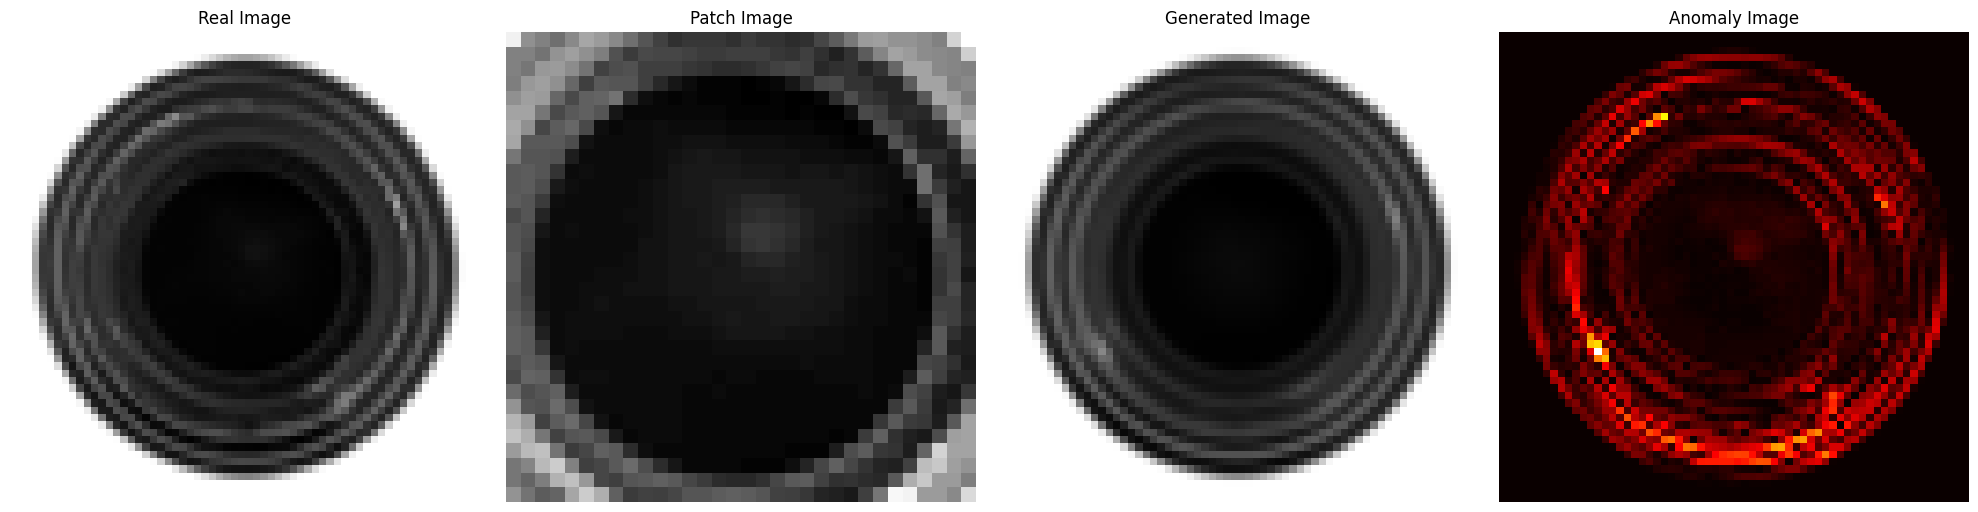

In [16]:
import matplotlib.pyplot as plt

# --- Helper Functions ---

def load_and_preprocess_image(image_path, img_size=(64,64)):
    """
    Loads an image, converts to grayscale, resizes and returns as a numpy array.
    Also returns the flattened normalized image.
    """
    img = Image.open(image_path).convert("L")
    img = img.resize(img_size)
    img_np = np.array(img, dtype=np.float32) / 255.0  # normalized [0,1]
    return img_np, img_np.flatten()

def extract_patch(image_np, patch_size=(32,32)):
    """
    Extract a central patch from the image.
    """
    h, w = image_np.shape
    ph, pw = patch_size
    start_h = (h - ph) // 2
    start_w = (w - pw) // 2
    return image_np[start_h:start_h+ph, start_w:start_w+pw]

# --- Load a Test Image ---
# For example, using a test image from the "good" folder.
test_image_path = "/kaggle/input/mvtec-ad/bottle/test/good/007.png"
print("Test image:", test_image_path)

# Load and preprocess the test image (returns image as 2D array and flattened vector)
real_img_np, real_img_flat = load_and_preprocess_image(test_image_path, img_size)
# Transform the flattened image into the 2D feature space (using the fitted PCA)
test_feature = pca.transform(real_img_flat.reshape(1, -1))  # shape (1, 2)

# --- Generate an Image from the Quantum Generator ---
# Sample a latent noise vector and pass through the generator
z_gen = torch.randn(1, n_qubits)  # batch size of 1
with torch.no_grad():
    gen_feature = qgen(z_gen.to(device))  # shape (1, 2)
# Make sure to convert to numpy and use CPU
gen_feature_np = gen_feature.cpu().numpy()

# Now use the inverse PCA transformation to reconstruct a flattened image.
# Note: This assumes that your PCA was fit on flattened images (e.g., 64x64 -> 4096 dimensions)
reconstructed_flat = pca.inverse_transform(gen_feature_np)  # shape (1, 4096)
# Reshape back to the original image shape
generated_img_np = reconstructed_flat.reshape(img_size)

# --- Compute the Anomaly Image ---
# Here we define the anomaly image as the absolute difference between the real and generated images.
anomaly_img_np = np.abs(real_img_np - generated_img_np)

# --- Extract a Patch Image from the Real Image ---
patch_img_np = extract_patch(real_img_np, patch_size=(32,32))

# --- Plot the Images in a Horizontal Line ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
# Real image
axes[0].imshow(real_img_np, cmap="gray")
axes[0].set_title("Real Image")
axes[0].axis("off")
# Patch image (displayed with its own size)
axes[1].imshow(patch_img_np, cmap="gray")
axes[1].set_title("Patch Image")
axes[1].axis("off")
# Generated image (reconstructed via inverse PCA from quantum generator)
axes[2].imshow(generated_img_np, cmap="gray")
axes[2].set_title("Generated Image")
axes[2].axis("off")
# Anomaly image (absolute difference)
axes[3].imshow(anomaly_img_np, cmap="hot")
axes[3].set_title("Anomaly Image")
axes[3].axis("off")

plt.tight_layout()
plt.show()


In [17]:
import os
import glob
import torch
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make sure your device is defined (e.g., from earlier code)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume these variables are already defined:
# - base_path (e.g., "/kaggle/input/mvtec-ad")
# - category (e.g., "bottle")
# - img_size (e.g., (64, 64))
# - pca (a fitted PCA model on your training data)
# - disc (your trained discriminator model)
# - load_and_preprocess_image(img_path, img_size) function

# --- Define the helper function for loading & preprocessing an image ---
def load_and_preprocess_image(image_path, img_size=(64,64)):
    """
    Loads an image, converts it to grayscale, resizes it and returns:
      - the 2D image array (for visualization)
      - the flattened, normalized array (for PCA transformation)
    """
    img = Image.open(image_path).convert("L")
    img = img.resize(img_size)
    img_np = np.array(img, dtype=np.float32) / 255.0  # normalized image in [0,1]
    return img_np, img_np.flatten()

# --- Prepare lists to hold test image information ---
image_paths = []
anomaly_scores = []
true_labels = []  # 1 for normal, 0 for anomaly

# Define the threshold used for prediction.
threshold = 0.5

# Set test paths
test_base = os.path.join(base_path, category, "test")
good_path = os.path.join(test_base, "good")
# All subfolders in test folder (excluding "good") are treated as anomaly types.
all_test_subfolders = [os.path.join(test_base, folder) for folder in os.listdir(test_base)]
anomaly_folders = [folder for folder in all_test_subfolders if os.path.basename(folder) != "good"]

# --- Process Good (Normal) Images ---
good_files = []
for ext in ["png", "jpg", "jpeg"]:
    good_files.extend(glob.glob(os.path.join(good_path, f"*.{ext}")))

for f in good_files:
    # Load and preprocess the image
    _, img_flat = load_and_preprocess_image(f, img_size)
    # Transform the flattened image using the fitted PCA model
    feature = pca.transform(img_flat.reshape(1, -1))
    feature_tensor = torch.tensor(feature, dtype=torch.float32).to(device)
    # Obtain the discriminator output (normality score)
    with torch.no_grad():
        score = disc(feature_tensor)
    image_paths.append(f)
    anomaly_scores.append(score.item())
    true_labels.append(1)  # Good images are labeled as normal (1)

# --- Process Anomaly Images ---
anomaly_files = []
for folder in anomaly_folders:
    for ext in ["png", "jpg", "jpeg"]:
        anomaly_files.extend(glob.glob(os.path.join(folder, f"*.{ext}")))
        
for f in anomaly_files:
    _, img_flat = load_and_preprocess_image(f, img_size)
    feature = pca.transform(img_flat.reshape(1, -1))
    feature_tensor = torch.tensor(feature, dtype=torch.float32).to(device)
    with torch.no_grad():
        score = disc(feature_tensor)
    image_paths.append(f)
    anomaly_scores.append(score.item())
    true_labels.append(0)  # Anomaly images are labeled as 0

# --- Compute predicted labels using the threshold ---
predicted_labels = [1 if score >= threshold else 0 for score in anomaly_scores]

# --- Compute overall performance metrics ---
acc = accuracy_score(true_labels, predicted_labels)
prec = precision_score(true_labels, predicted_labels)
rec = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)
conf_mat = confusion_matrix(true_labels, predicted_labels)

# Create a summary DataFrame for model accuracy metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [acc, prec, rec, f1]
})

print("Model Accuracy Score Table:")
print(metrics_df.to_string(index=False))
print("\nConfusion Matrix:")
print(conf_mat)

# --- Create a detailed anomaly score table ---
anomaly_table = pd.DataFrame({
    "Image Path": image_paths,
    "Anomaly Score": anomaly_scores,
    "True Label": true_labels,
    "Predicted Label": predicted_labels
})
print("\nAnomaly Score Table (first 10 entries):")
print(anomaly_table.head(10).to_string(index=False))


Model Accuracy Score Table:
   Metric    Score
 Accuracy 0.397590
Precision 0.187500
   Recall 0.450000
 F1 Score 0.264706

Confusion Matrix:
[[24 39]
 [11  9]]

Anomaly Score Table (first 10 entries):
                                     Image Path  Anomaly Score  True Label  Predicted Label
/kaggle/input/mvtec-ad/bottle/test/good/007.png       0.262954           1                0
/kaggle/input/mvtec-ad/bottle/test/good/016.png       0.321292           1                0
/kaggle/input/mvtec-ad/bottle/test/good/005.png       0.957830           1                1
/kaggle/input/mvtec-ad/bottle/test/good/011.png       0.235902           1                0
/kaggle/input/mvtec-ad/bottle/test/good/013.png       0.305807           1                0
/kaggle/input/mvtec-ad/bottle/test/good/017.png       0.989466           1                1
/kaggle/input/mvtec-ad/bottle/test/good/004.png       0.236703           1                0
/kaggle/input/mvtec-ad/bottle/test/good/018.png       0.307039

Test image: /kaggle/input/mvtec-ad/bottle/test/good/000.png


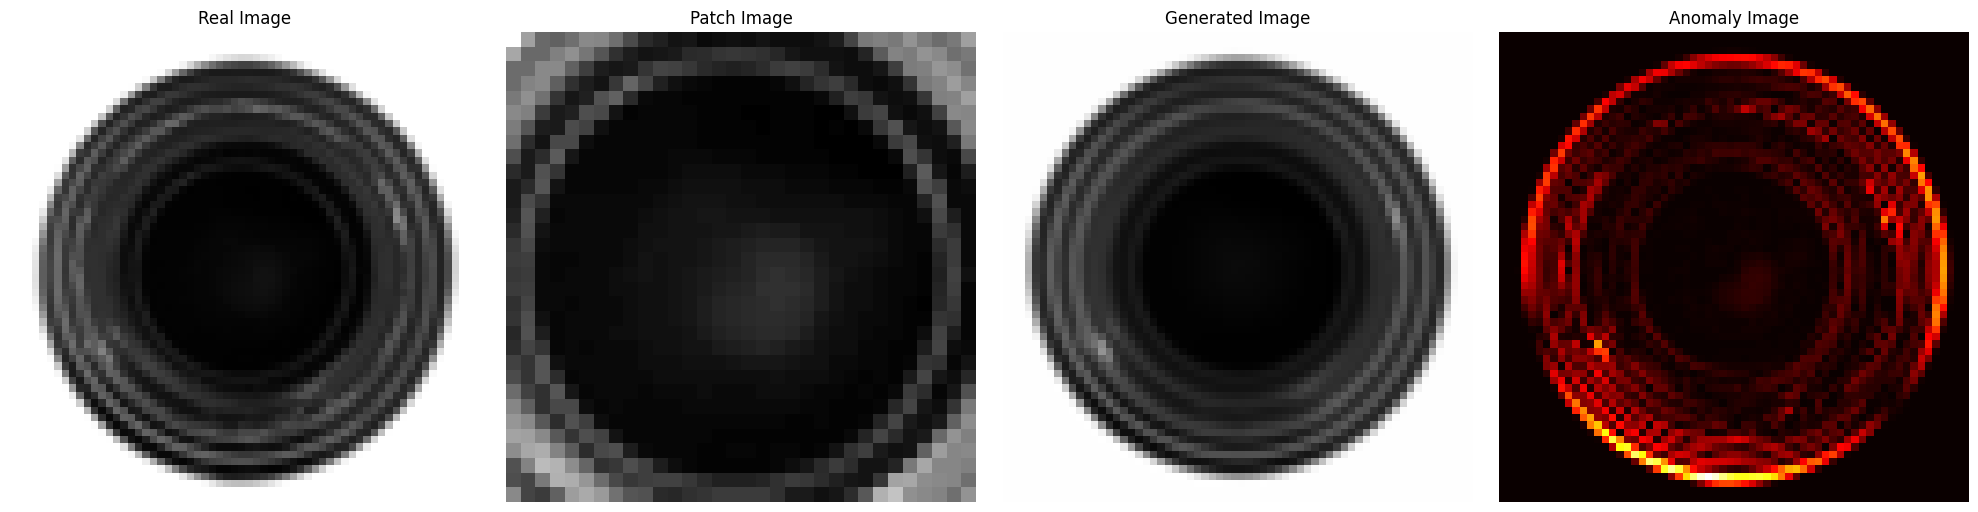

In [18]:
import matplotlib.pyplot as plt

# --- Helper Functions ---

def load_and_preprocess_image(image_path, img_size=(64,64)):
    """
    Loads an image, converts to grayscale, resizes and returns as a numpy array.
    Also returns the flattened normalized image.
    """
    img = Image.open(image_path).convert("L")
    img = img.resize(img_size)
    img_np = np.array(img, dtype=np.float32) / 255.0  # normalized [0,1]
    return img_np, img_np.flatten()

def extract_patch(image_np, patch_size=(32,32)):
    """
    Extract a central patch from the image.
    """
    h, w = image_np.shape
    ph, pw = patch_size
    start_h = (h - ph) // 2
    start_w = (w - pw) // 2
    return image_np[start_h:start_h+ph, start_w:start_w+pw]

# --- Load a Test Image ---
# For example, using a test image from the "good" folder.
test_image_path = "/kaggle/input/mvtec-ad/bottle/test/good/000.png"
print("Test image:", test_image_path)

# Load and preprocess the test image (returns image as 2D array and flattened vector)
real_img_np, real_img_flat = load_and_preprocess_image(test_image_path, img_size)
# Transform the flattened image into the 2D feature space (using the fitted PCA)
test_feature = pca.transform(real_img_flat.reshape(1, -1))  # shape (1, 2)

# --- Generate an Image from the Quantum Generator ---
# Sample a latent noise vector and pass through the generator
z_gen = torch.randn(1, n_qubits)  # batch size of 1
with torch.no_grad():
    gen_feature = qgen(z_gen.to(device))  # shape (1, 2)
# Make sure to convert to numpy and use CPU
gen_feature_np = gen_feature.cpu().numpy()

# Now use the inverse PCA transformation to reconstruct a flattened image.
# Note: This assumes that your PCA was fit on flattened images (e.g., 64x64 -> 4096 dimensions)
reconstructed_flat = pca.inverse_transform(gen_feature_np)  # shape (1, 4096)
# Reshape back to the original image shape
generated_img_np = reconstructed_flat.reshape(img_size)

# --- Compute the Anomaly Image ---
# Here we define the anomaly image as the absolute difference between the real and generated images.
anomaly_img_np = np.abs(real_img_np - generated_img_np)

# --- Extract a Patch Image from the Real Image ---
patch_img_np = extract_patch(real_img_np, patch_size=(32,32))

# --- Plot the Images in a Horizontal Line ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
# Real image
axes[0].imshow(real_img_np, cmap="gray")
axes[0].set_title("Real Image")
axes[0].axis("off")
# Patch image (displayed with its own size)
axes[1].imshow(patch_img_np, cmap="gray")
axes[1].set_title("Patch Image")
axes[1].axis("off")
# Generated image (reconstructed via inverse PCA from quantum generator)
axes[2].imshow(generated_img_np, cmap="gray")
axes[2].set_title("Generated Image")
axes[2].axis("off")
# Anomaly image (absolute difference)
axes[3].imshow(anomaly_img_np, cmap="hot")
axes[3].set_title("Anomaly Image")
axes[3].axis("off")

plt.tight_layout()
plt.show()


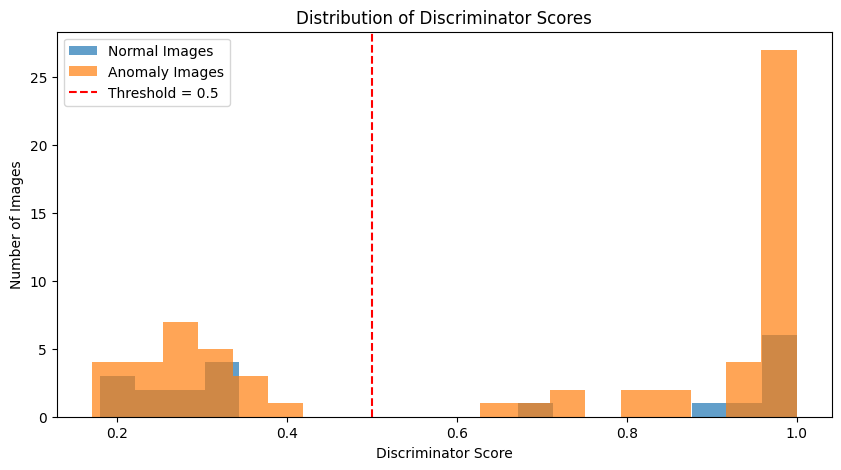

Threshold: 0.3  ->  Accuracy: 0.337
Threshold: 0.4  ->  Accuracy: 0.398
Threshold: 0.5  ->  Accuracy: 0.398
Threshold: 0.6  ->  Accuracy: 0.398
Threshold: 0.7  ->  Accuracy: 0.398


In [19]:
import matplotlib.pyplot as plt

# Separate scores for normal and anomaly images based on true labels
normal_scores = [s for s, t in zip(anomaly_scores, true_labels) if t == 1]
anomaly_scores_list = [s for s, t in zip(anomaly_scores, true_labels) if t == 0]

plt.figure(figsize=(10, 5))
plt.hist(normal_scores, bins=20, alpha=0.7, label='Normal Images')
plt.hist(anomaly_scores_list, bins=20, alpha=0.7, label='Anomaly Images')
plt.axvline(threshold, color='red', linestyle='--', label=f"Threshold = {threshold}")
plt.xlabel("Discriminator Score")
plt.ylabel("Number of Images")
plt.title("Distribution of Discriminator Scores")
plt.legend()
plt.show()

# Optionally, you can experiment with different thresholds:
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_labels_temp = [1 if s >= th else 0 for s in anomaly_scores]
    acc_temp = accuracy_score(true_labels, pred_labels_temp)
    print(f"Threshold: {th:.1f}  ->  Accuracy: {acc_temp:.3f}")


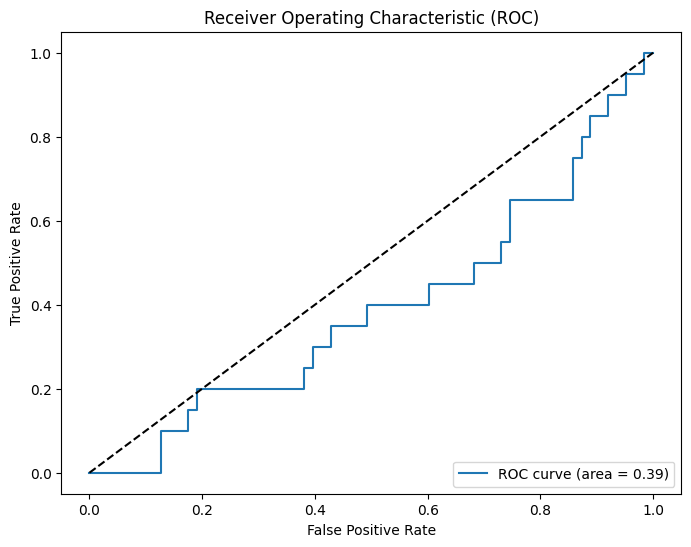

In [20]:
from sklearn.metrics import roc_curve, auc

# Calculate false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(true_labels, anomaly_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()
